In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [17]:
athletes = pd.read_csv("athlete_events.csv")
regions = pd.read_csv("noc_regions.csv")
df = athletes.merge(regions, on="NOC", how="left")

In [18]:
df["Medal_binary"] = df["Medal"].apply(lambda x: 0 if pd.isna(x) else 1)

In [19]:
df = df[["Age","Sex","Sport","Height","Weight","Season","Medal_binary"]].dropna()

In [20]:
X = df.drop("Medal_binary",axis=1)
y = df["Medal_binary"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [21]:
categorical_features = ["Sex","Sport","Season"]
numerical_features = ["Age","Height","Weight"]

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", "passthrough", numerical_features)
    ])

clf = Pipeline(
    steps=[
        ("preprocessor", preprocess),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42))
    ])

In [22]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.8263769310988771
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     35190
           1       0.33      0.19      0.24      6043

    accuracy                           0.83     41233
   macro avg       0.60      0.56      0.57     41233
weighted avg       0.79      0.83      0.80     41233



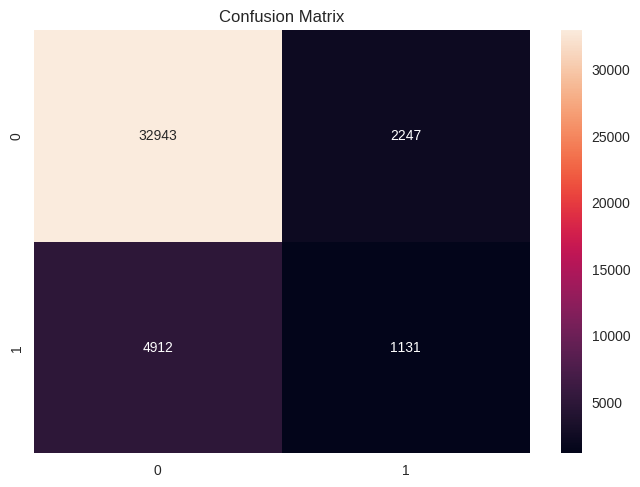

In [23]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()